In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
df = pd.read_csv("dataset/german_credit_data.csv")

In [80]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [81]:
df.drop(columns = "Unnamed: 0", inplace = True)

In [82]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Risk,1000,2,good,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
df["Job"].unique()

array([2, 1, 3, 0])

In [84]:
df.shape

(1000, 10)

In [85]:
df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [86]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [87]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [88]:
df.duplicated().sum()

np.int64(0)

In [89]:
df = df.dropna().reset_index(drop=True)

In [90]:
df.shape

(522, 10)

In [91]:
pd.set_option("display.max_columns", None)

In [92]:
sns.set_style("whitegrid")

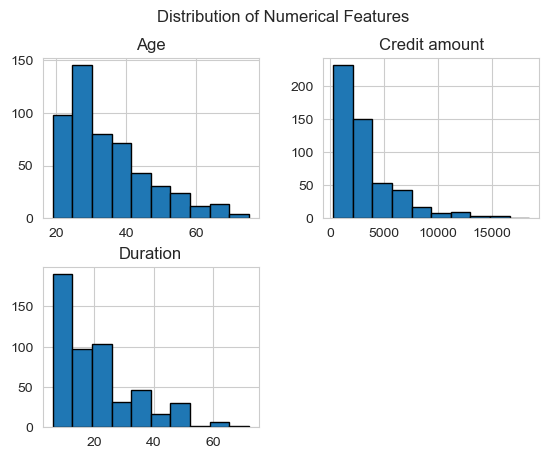

In [93]:
df[["Age", "Credit amount", "Duration"]].hist(bins = 10, edgecolor = "black")
plt.suptitle("Distribution of Numerical Features")
plt.show()

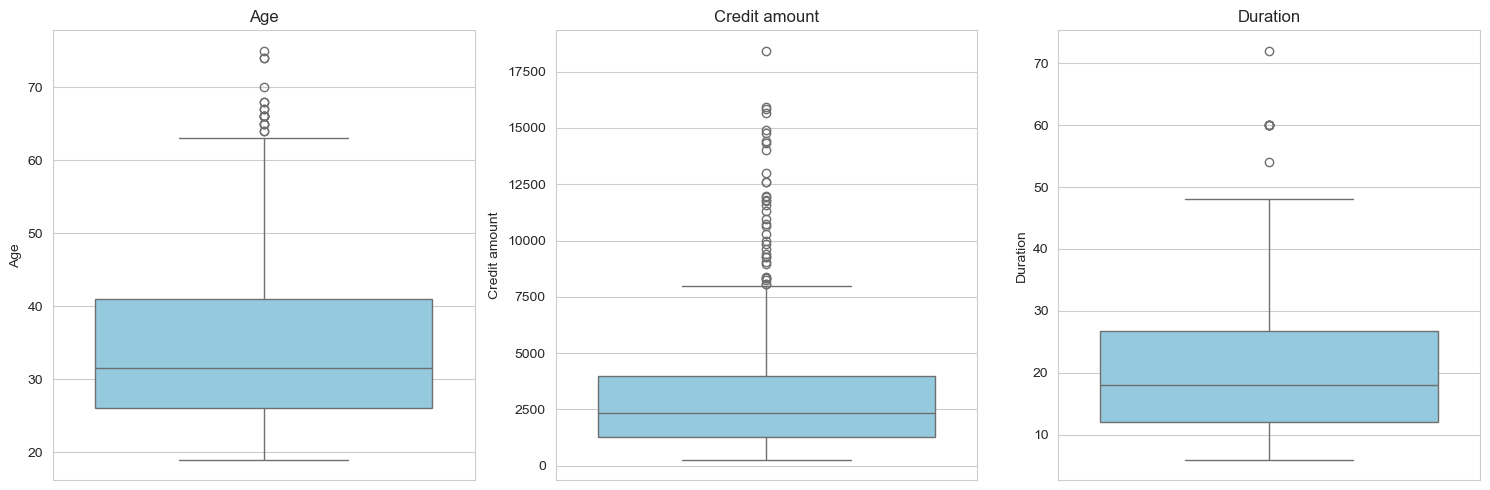

In [94]:
plt.figure(figsize = ( 15,5))
for i, col in enumerate (["Age", "Credit amount", "Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col], color = "skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

In [95]:
df.query("Duration>60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [96]:
categorical_cols = ["Sex", "Job", "Housing", "Saving accounts", "Checking account", "Purpose"]

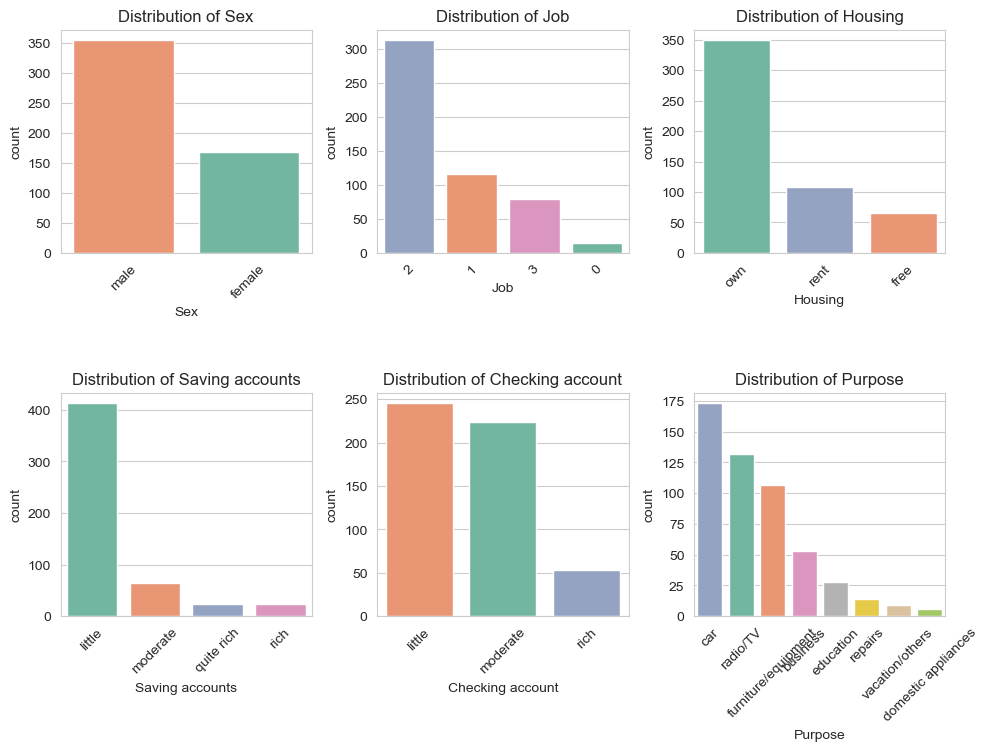

In [97]:
plt.figure(figsize=(10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(
        data=df,
        x=col,
        hue=col,
        palette="Set2",
        order=df[col].value_counts().index,
        legend=False
    )
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [98]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()

In [99]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


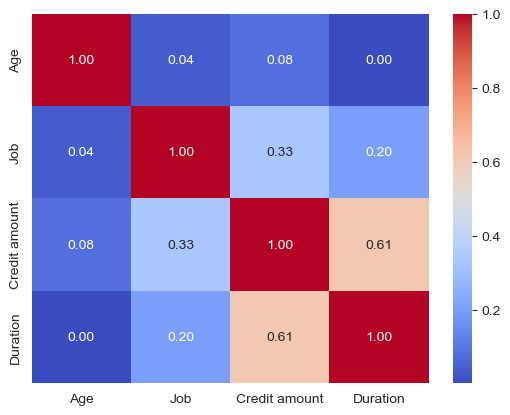

In [100]:
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt = ".2f")
plt.show()

In [101]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [102]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [103]:
pd.pivot_table(df, values = "Credit amount", index = "Housing", columns = "Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


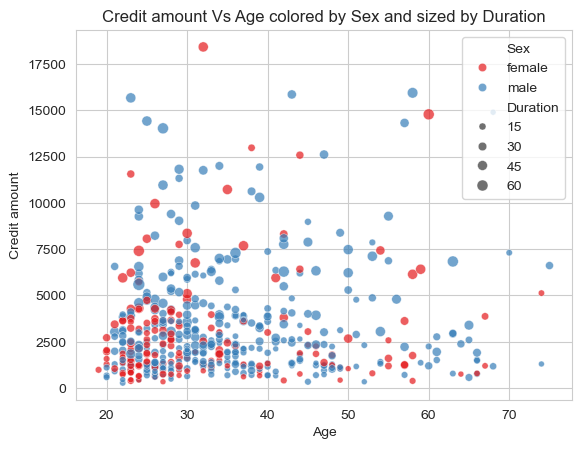

In [104]:
sns.scatterplot(data = df, x = "Age", y = "Credit amount", hue = "Sex", size = "Duration",alpha = 0.7, palette = "Set1")
plt.title("Credit amount Vs Age colored by Sex and sized by Duration")
plt.show()

C:\Users\Ademola\AppData\Local\Temp\ipykernel_248\2490299925.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data =df, x = "Saving accounts", y = "Credit amount", palette = "Pastel1")


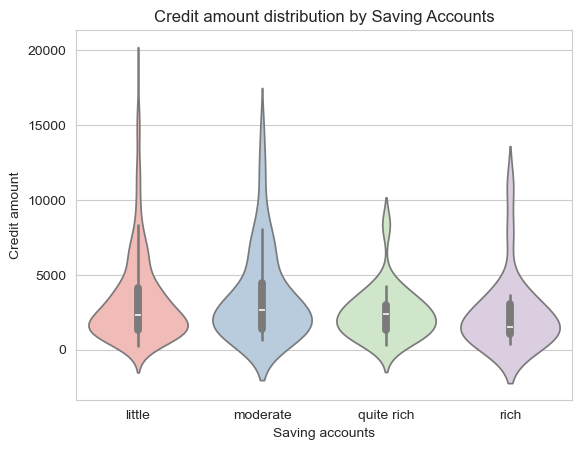

In [105]:
sns.violinplot(data =df, x = "Saving accounts", y = "Credit amount", palette = "Pastel1")
plt.title("Credit amount distribution by Saving Accounts")
plt.show()

In [106]:
df["Risk"].value_counts(normalize = True) *100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\Ademola\AppData\Local\Temp\ipykernel_248\2049736158.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x= "Risk", y = col, palette = "Pastel1")
C:\Users\Ademola\AppData\Local\Temp\ipykernel_248\2049736158.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x= "Risk", y = col, palette = "Pastel1")
C:\Users\Ademola\AppData\Local\Temp\ipykernel_248\2049736158.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, x= "Risk", y = col, palette = "Pastel1")


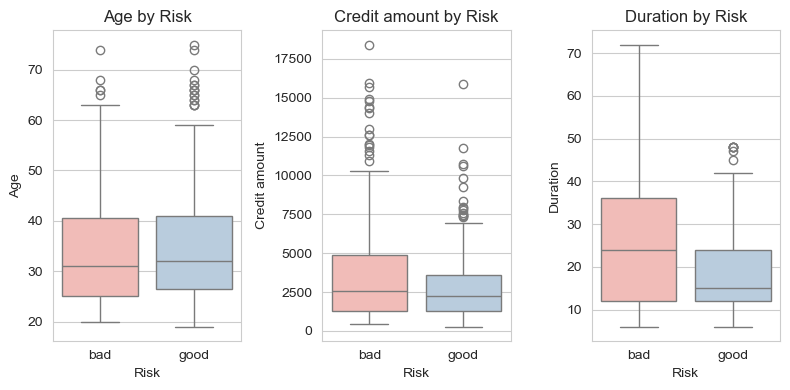

In [107]:
plt.figure(figsize=(8,4))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1,3, i+1)
    sns.boxplot(data = df, x= "Risk", y = col, palette = "Pastel1")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

In [108]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


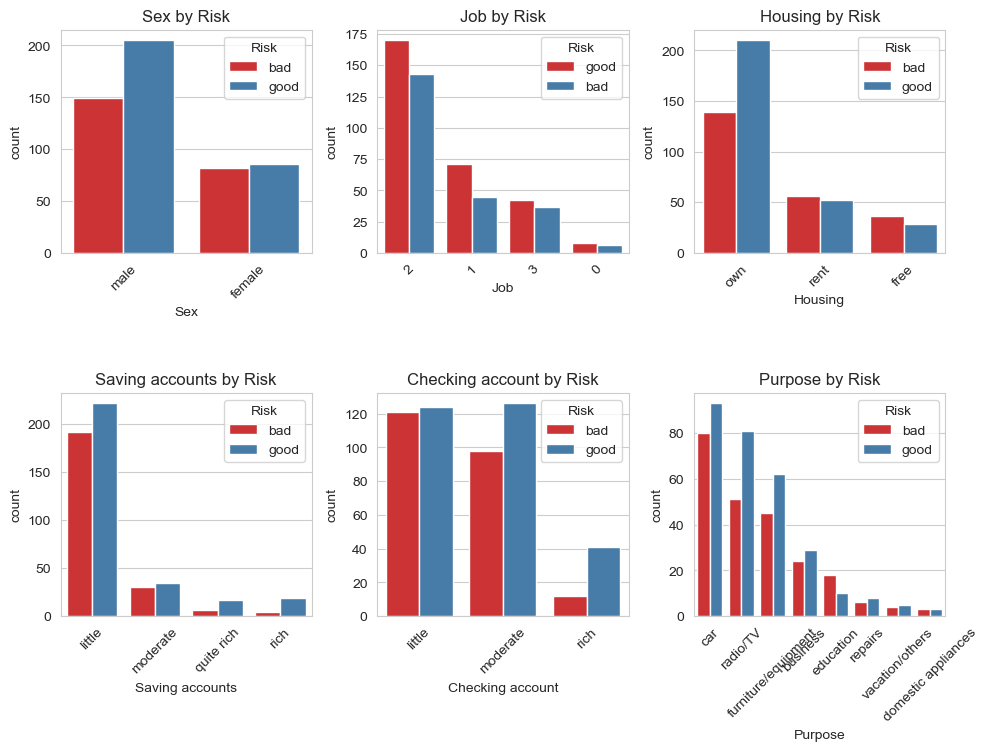

In [109]:
plt.figure(figsize = (10,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data = df, x = col, hue = "Risk", palette = "Set1", order = df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [110]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [111]:
features = ["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account", "Credit amount", "Duration"]

In [112]:
target = "Risk"

In [113]:
df_model = df[features + [target]].copy()

In [114]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [115]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [116]:
cat_cols = df_model.select_dtypes(include = "object").columns.drop("Risk")

In [117]:
le_dict = {}

In [118]:
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] =le
    joblib.dump(le, f"{col}_encoder.pkl") 

In [119]:
le_target = LabelEncoder()

In [120]:
target

'Risk'

In [121]:
df_model[target] = le_target.fit_transform(df_model[target])

In [122]:
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [123]:
joblib.dump(le_target, "target_encoder.pkl")

['target_encoder.pkl']

In [124]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [125]:
from sklearn.model_selection import  train_test_split

In [126]:
X = df_model.drop(target, axis = 1)

In [127]:
y =df_model[target]

In [128]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [129]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [130]:
X_test.shape

(105, 8)

In [131]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [132]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv = 3, scoring = "accuracy", n_jobs = -1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [133]:
dt = DecisionTreeClassifier(random_state = 1, class_weight = "balanced")
dt_param_grid = {
    "max_depth": [3,5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}

In [134]:
best_dt, acc_dt, param_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test) 

In [135]:
print("Decision Tree Accuracy", acc_dt)

Decision Tree Accuracy 0.4857142857142857


In [136]:
print("Best Parameter", param_dt)

Best Parameter {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [137]:
rf = RandomForestClassifier(random_state = 1, class_weight = "balanced", n_jobs =-1)

In [138]:
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5,7,10, None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
    
}

In [139]:
best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [140]:
print("Random Forest Accuracy", acc_rf)

Random Forest Accuracy 0.6095238095238096


In [141]:
print("Best parameter", params_rf)

Best parameter {'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [142]:
et = ExtraTreesClassifier(random_state = 1, class_weight = "balanced", n_jobs = -1)

In [143]:
et_param_grid = {
     "n_estimators": [100, 200],
     "max_depth": [5,7,10, None],
     "min_samples_split": [2,5,10],
     "min_samples_leaf": [1,2,4]
    
}

In [144]:
best_et, acc_et, params_et =  train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [145]:
print("Extra trees accuracy", acc_et)
print("Best Params", params_et)

Extra trees accuracy 0.49523809523809526
Best Params {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [146]:
xgb = XGBClassifier(random_state = 1, scale_pos_weight = (y_train ==0).sum() / (y_train == 1).sum(), use_label_encoder = False, eval_metric = "logloss")

In [147]:
xgb_param_grid = {
    "n_estimators" : [100, 200],
    "max_depth" : [3,5,7],
    "learning_rate": [0.01, 0.1, 0.2],
    "subsample" : [0.7, 1],
    "colsample_bytree" : [0.7, 1]
}

In [148]:
best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

C:\Users\Ademola\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:30:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [149]:
print("XGB accuracy", acc_xgb)
print("Best Params", params_xgb)

XGB accuracy 0.5619047619047619
Best Params {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1}


In [150]:
best_et.predict(X_test)

array([1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0])

In [151]:
joblib.dump(best_et, "extra_trees_credit_models.pkl")

['extra_trees_credit_models.pkl']